<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/FrozenLake_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install gymnasium
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [27]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode=None)
state_space = env.observation_space.n
action_space = env.action_space.n

print(f"State space size: {state_space}")
print(f"Action space size: {action_space}")

State space size: 16
Action space size: 4


In [23]:
# Hyperparameters
total_episodes = 5000       # Total training runs
learning_rate = 0.8         # Alpha: How much to prioritize new info
gamma = 0.95                # Gamma: How much to prioritize future rewards
epsilon = 1.0               # Exploration rate
max_epsilon = 1.0           # Starting epsilon
min_epsilon = 0.01          # Minimum exploration rate
decay_rate = 0.005          # How fast epsilon decreases

In [24]:
q_table = np.zeros((state_space, action_space))
print("Initial Q-Table (zeros):")
print(q_table)

Initial Q-Table (zeros):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [25]:
total_episodes = 2000
learning_rate = 0.8
gamma = 0.95
epsilon = 1.0  # Start with 100% exploration
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.005

In [29]:
rewards = []

for episode in range(total_episodes):
    state, _ = env.reset()
    done = False

    for step in range(100): # Max steps per episode
        # Epsilon-Greedy Strategy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(q_table[state, :]) # Exploit

        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-Learning Formula
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action]
        )

        state = new_state
        if done:
            break

    # Decay epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

print("Training finished!")
print("Learned Q-Table:")
print(q_table)

Training finished!
Learned Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
print("Learned Q-Table:")
print(q_table)

# Create a new environment instance for rendering the test episode
render_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")

state, info = render_env.reset()
done = False

print("\nPath taken (visualized):")
frames = []
step_count = 0
while not done:
    frames.append(render_env.render())

    action = np.argmax(q_table[state, :])
    new_state, reward, terminated, truncated, _ = render_env.step(action)

    state = new_state
    done = terminated or truncated
    step_count += 1

# Add the final frame if the loop ended
if done:
    frames.append(render_env.render())

render_env.close()

# Display all collected frames
fig, axes = plt.subplots(1, len(frames), figsize=(len(frames) * 4, 4))
if len(frames) == 1:
    axes = [axes]

for i, frame in enumerate(frames):
    axes[i].imshow(frame)
    axes[i].set_title(f"Step {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
!pip install gymnasium
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [14]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="human")
state_space = env.observation_space.n
action_space = env.action_space.n

print(f"State space size: {state_space}")
print(f"Action space size: {action_space}")

State space size: 16
Action space size: 4


In [15]:
# Hyperparameters
total_episodes = 5000       # Total training runs
learning_rate = 0.8         # Alpha: How much to prioritize new info
gamma = 0.95                # Gamma: How much to prioritize future rewards
epsilon = 1.0               # Exploration rate
max_epsilon = 1.0           # Starting epsilon
min_epsilon = 0.01          # Minimum exploration rate
decay_rate = 0.005          # How fast epsilon decreases

In [11]:
for episode in range(total_episodes):
    state, info = env.reset()
    done = False

    for step in range(100):
        # Epsilon-Greedy Action Selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(q_table[state, :]) # Exploit

        # Perform action
        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-Learning Update Equation (Bellman Equation)
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action]
        )

        state = new_state
        if done:
            break

    # Decay epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

print("Training Complete!")

Training Complete!


In [16]:
q_table = np.zeros((state_space, action_space))
print("Initial Q-Table (zeros):")
print(q_table)

Initial Q-Table (zeros):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [17]:
total_episodes = 2000
learning_rate = 0.8
gamma = 0.95
epsilon = 1.0  # Start with 100% exploration
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.005

In [28]:
rewards = []

for episode in range(total_episodes):
    state, _ = env.reset()
    done = False

    for step in range(100): # Max steps per episode
        # Epsilon-Greedy Strategy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(q_table[state, :]) # Exploit

        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-Learning Formula
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action]
        )

        state = new_state
        if done:
            break

    # Decay epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

print("Training finished!")
print("Learned Q-Table:")
print(q_table)

Training finished!
Learned Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


Learned Q-Table:
[[0.7350916  0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.         0.        ]
 [0.55866609 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450621 0.         0.857375   0.77367501]
 [0.81450557 0.90249986 0.9025     0.        ]
 [0.85737269 0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.722      0.95       0.68547656]
 [0.90243226 0.94999912 1.         0.90249991]
 [0.         0.         0.         0.        ]]

Path taken (visualized):


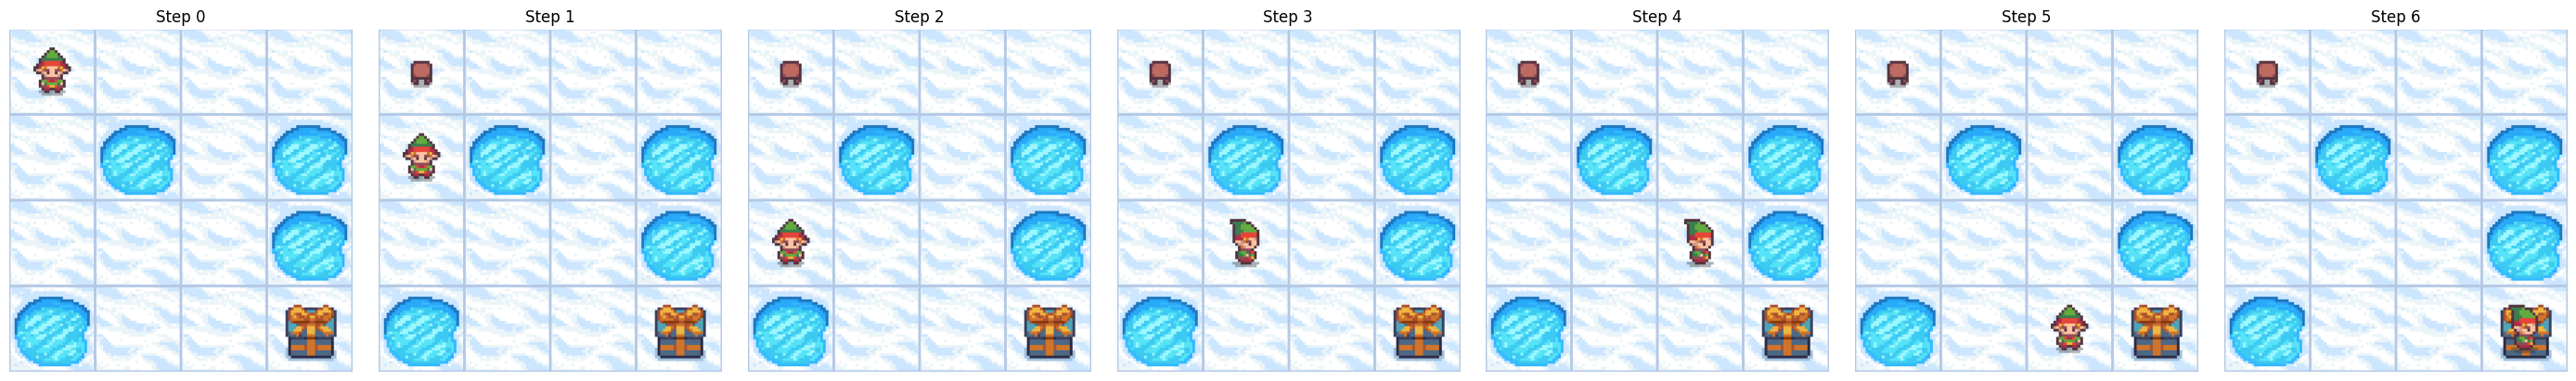

In [19]:
print("Learned Q-Table:")
print(q_table)

# Create a new environment instance for rendering the test episode
render_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")

state, info = render_env.reset()
done = False

print("\nPath taken (visualized):")
frames = []
step_count = 0
while not done:
    frames.append(render_env.render())

    action = np.argmax(q_table[state, :])
    new_state, reward, terminated, truncated, _ = render_env.step(action)

    state = new_state
    done = terminated or truncated
    step_count += 1

# Add the final frame if the loop ended
if done:
    frames.append(render_env.render())

render_env.close()

# Display all collected frames
fig, axes = plt.subplots(1, len(frames), figsize=(len(frames) * 4, 4))
if len(frames) == 1:
    axes = [axes]

for i, frame in enumerate(frames):
    axes[i].imshow(frame)
    axes[i].set_title(f"Step {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()